# Lab 10 – Iris Dataset EDA: Histograms, Boxplots & Outliers
### Aim
- List features and their types.
- Create histograms and boxplots for each feature.
- Compare distributions and identify outliers.

-pip install pandas numpy matplotlib seaborn scikit-learn nltk

In [1]:
# Cell 1 – Importing Packages
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Cell 2 – Load Dataset
iris = sns.load_dataset('iris')

print('Dataset shape:', iris.shape)
iris.head()

Dataset shape: (150, 5)


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [3]:
# Cell 3 – Feature Types
feature_types = iris.dtypes
print('Feature types:')
print(feature_types)

numeric_features     = iris.select_dtypes(include=['float64', 'int64']).columns.tolist()
categorical_features = iris.select_dtypes(include=['object', 'category']).columns.tolist()

print('\nNumeric features    :', numeric_features)
print('Categorical features:', categorical_features)

Feature types:
sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
species             str
dtype: object

Numeric features    : ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']
Categorical features: ['species']


C:\Users\GAJENDRA\AppData\Local\Temp\ipykernel_8124\3813907902.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = iris.select_dtypes(include=['object', 'category']).columns.tolist()


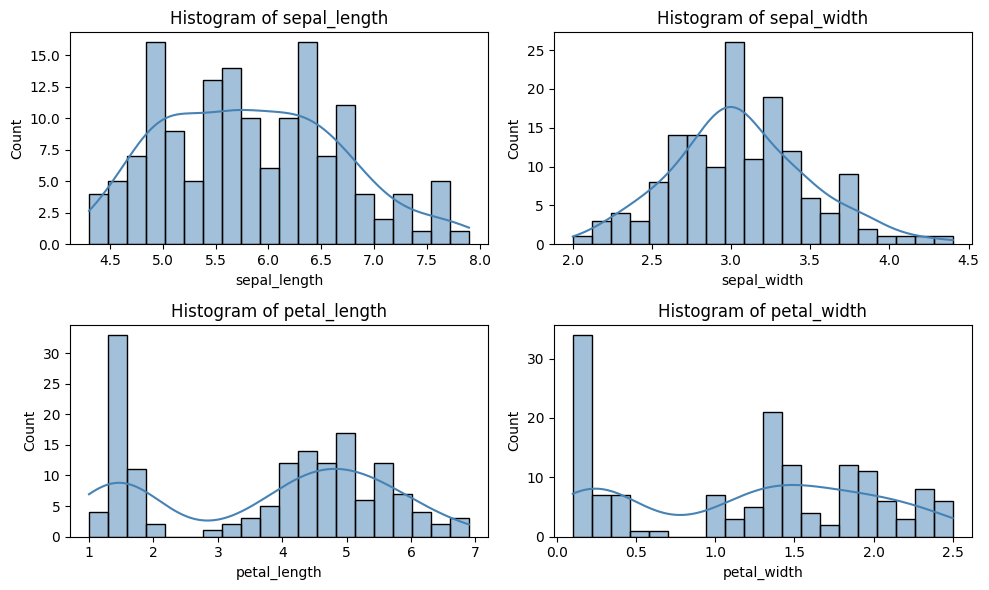

In [4]:
# Cell 4 – Histograms for Each Feature
plt.figure(figsize=(10, 6))

for i, col in enumerate(numeric_features, 1):
    plt.subplot(2, 2, i)
    sns.histplot(iris[col], kde=True, bins=20, color='steelblue')
    plt.title(f'Histogram of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')

plt.tight_layout()
plt.show()

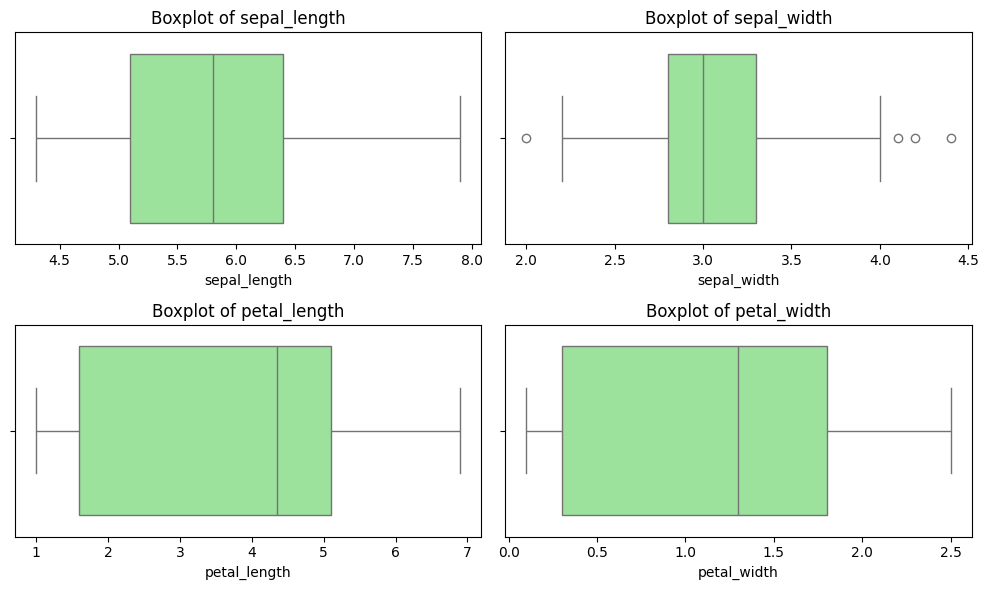

In [5]:
# Cell 5 – Boxplots for Each Feature
plt.figure(figsize=(10, 6))

for i, col in enumerate(numeric_features, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(x=iris[col], color='lightgreen')
    plt.title(f'Boxplot of {col}')
    plt.xlabel(col)

plt.tight_layout()
plt.show()

In [6]:
# Cell 6 – Compare Distributions & Identify Outliers (IQR Method)
outlier_summary = {}

for col in numeric_features:
    q1  = iris[col].quantile(0.25)
    q3  = iris[col].quantile(0.75)
    iqr = q3 - q1
    lower   = q1 - 1.5 * iqr
    upper   = q3 + 1.5 * iqr
    outliers = iris[(iris[col] < lower) | (iris[col] > upper)][col]
    outlier_summary[col] = {
        'Q1': q1, 'Q3': q3, 'IQR': iqr,
        'Lower Fence': lower, 'Upper Fence': upper,
        'Outlier Count': outliers.count(),
    }

outlier_df = pd.DataFrame(outlier_summary).T
print('Outlier Summary (IQR Method):\n')
outlier_df

Outlier Summary (IQR Method):



,Q1,Q3,IQR,Lower Fence,Upper Fence,Outlier Count
sepal_length,5.1,6.4,1.3,3.15,8.35,0.0
sepal_width,2.8,3.3,0.5,2.05,4.05,4.0
petal_length,1.6,5.1,3.5,-3.65,10.35,0.0
petal_width,0.3,1.8,1.5,-1.95,4.05,0.0
